<a href="https://colab.research.google.com/github/bintangrz2704/UTS-DatMin/blob/main/UTS_DATMIN_Ricky_Bintang_Zakaria_(2304020015).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Persiapan Data**

In [1]:
#Upload dataset training dan testing
from google.colab import files
uploaded = files.upload()

Saving data_testing.csv to data_testing.csv
Saving data_training.csv to data_training.csv


Pada tahap awal, file data_training.csv dan data_testing.csv diunggah ke Google Colab. Dataset training digunakan untuk membangun model klasifikasi karena memiliki kolom target quality, sedangkan dataset testing digunakan pada tahap akhir untuk menghasilkan prediksi kualitas anggur. Data testing tidak digunakan dalam proses pelatihan model karena belum memiliki nilai target quality.

In [2]:
#Import library untuk membaca data
import pandas as pd

Library pandas digunakan untuk membaca dan mengolah data dalam bentuk tabel atau dataframe. Dalam analisis ini, pandas berfungsi untuk membaca file CSV, menampilkan isi data, memeriksa struktur data, memisahkan fitur dan target, serta membuat file hasil prediksi.

In [3]:
#Membaca file data_training.csv dan menyimpannya ke variabel data_train
data_train = pd.read_csv("data_training.csv")

#Membaca file data_testing.csv dan menyimpannya ke variabel data_test
data_test = pd.read_csv("data_testing.csv")

Dataset training dan testing dibaca menggunakan fungsi pd.read_csv().

In [4]:
#Menampilkan 5 baris pertama dari data training
data_train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


In [5]:
##Menampilkan 5 baris pertama dari data testing
data_test.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8,0.61,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222
1,6.9,0.84,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514
2,7.0,0.58,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417
3,7.8,0.48,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754
4,12.5,0.60,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516


Setelah data berhasil dibaca, fungsi head() digunakan untuk menampilkan lima baris pertama dari masing-masing dataset.

In [6]:
#Menampilkan ukuran data training
print("Ukuran data training:", data_train.shape)

#Menampilkan ukuran data testing
print("Ukuran data testing:", data_test.shape)

Ukuran data training: (857, 13)
Ukuran data testing: (286, 12)


Tahap ini dilakukan untuk mengetahui jumlah baris dan jumlah kolom pada data training serta data testing. Ukuran dataset membantu memberikan gambaran awal tentang banyaknya data yang tersedia untuk proses pelatihan dan prediksi.
Data training digunakan untuk proses pembelajaran model, sedangkan data testing digunakan untuk prediksi akhir. Perbedaan jumlah kolom antara data training dan testing wajar terjadi karena data training memiliki kolom quality, sedangkan data testing tidak memiliki kolom tersebut.

In [7]:
#Menampilkan struktur data training, seperti nama kolom, tipe data, dan jumlah data non-null
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB


Fungsi info() digunakan untuk melihat struktur data training, seperti nama kolom, jumlah data non-null, dan tipe data setiap variabel. Tahap ini penting untuk memastikan bahwa semua variabel yang digunakan dalam model sudah berada dalam tipe data yang sesuai.
Dari informasi data training, dapat diketahui apakah terdapat nilai kosong

In [8]:
#Menampilkan struktur data testing, seperti nama kolom, tipe data, dan jumlah data non-null
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         286 non-null    float64
 1   volatile acidity      286 non-null    float64
 2   citric acid           286 non-null    float64
 3   residual sugar        286 non-null    float64
 4   chlorides             286 non-null    float64
 5   free sulfur dioxide   286 non-null    float64
 6   total sulfur dioxide  286 non-null    float64
 7   density               286 non-null    float64
 8   pH                    286 non-null    float64
 9   sulphates             286 non-null    float64
 10  alcohol               286 non-null    float64
 11  Id                    286 non-null    int64  
dtypes: float64(11), int64(1)
memory usage: 26.9 KB


Informasi data testing juga diperiksa untuk memastikan struktur data testing sesuai dengan data training. Data testing harus memiliki fitur yang sama dengan data training, kecuali kolom quality.
Pemeriksaan ini penting karena model hanya dapat memprediksi data testing apabila nama dan jumlah fitur yang digunakan sama dengan fitur saat model dilatih. Jika terdapat perbedaan kolom, maka model tidak dapat memproses data testing dengan benar.

In [9]:
## Menampilkan statistik deskriptif data training, seperti mean, standar deviasi, minimum, maksimum, dan kuartil
data_train.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000
mean,8.261960,0.529393,0.267351,2.506184,0.086830,15.782964,45.978413,0.996692,3.313092,0.656709,10.430338,5.653442,813.749125
std,1.701992,0.179162,0.195144,1.293512,0.048721,10.300402,31.692113,0.001901,0.152079,0.167364,1.066971,0.821777,463.807063
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.390000,8.400000,3.000000,0.000000
25%,7.100000,0.395000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995520,3.210000,0.550000,9.500000,5.000000,413.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,14.000000,38.000000,0.996680,3.310000,0.620000,10.200000,6.000000,814.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,63.000000,0.997800,3.400000,0.730000,11.100000,6.000000,1214.000000
max,15.600000,1.580000,1.000000,15.500000,0.611000,68.000000,278.000000,1.003200,4.010000,2.000000,14.000000,8.000000,1597.000000


Statistik deskriptif digunakan untuk melihat gambaran umum setiap variabel numerik pada data training. Informasi yang ditampilkan meliputi nilai rata-rata, standar deviasi, nilai minimum, maksimum, dan kuartil.

**2. Pembersihan Data (Mengecek Nilai Missing Value)**
Pengecekan missing value dilakukan untuk mengetahui apakah terdapat nilai kosong pada data training dan data testing. Missing value perlu diperiksa karena nilai kosong dapat mengganggu proses pelatihan model dan prediksi.

Jika hasil pengecekan menunjukkan tidak terdapat missing value, maka data dapat langsung digunakan untuk tahap berikutnya. Namun, apabila terdapat missing value, perlu dilakukan penanganan seperti imputasi atau penghapusan data. Pada analisis ini, tahap pengecekan missing value menunjukkan bahwa data sudah siap digunakan untuk proses modeling.

In [10]:
#Mengecek jumlah missing value pada setiap kolom pada data training
print("Missing value pada data training:")
print(data_train.isnull().sum())

Missing value pada data training:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


Disini terlihat bahwa data training tidak memiliki missing values

In [11]:
#Mengecek jumlah missing value pada setiap kolom pada data testing
print("Missing value pada data testing:")
print(data_test.isnull().sum())

Missing value pada data testing:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
Id                      0
dtype: int64


Disini terlihat bahwa data testing tidak memiliki missing values

Karena pada pengecekan pada data training dan data testing tidak ada missing values, jadi, kita bisa lanjut ke tahap selanjutnya

In [12]:
# Menampilkan jumlah data pada setiap kelas quality pada data training
data_train["quality"].value_counts().sort_index()

,count
quality,
3,6
4,26
5,362
6,341
7,109
8,13


Disini kita bisa mengecek persebaran quality pada data training. Tabel di atas menunjukkan pada data training Wine Quality yang memiliki kualitas 3 ada 6 Id, kualitas 4 ada 26 Id, kualitas 5vada 362 Id, kualitas 6 ada 341 Id, kualitas 7 ada 109 Id, dan kualitas 8 ada 13 Id

In [13]:
# Mengimport library matplotlib dan seaborn untuk membuat visualisasi data
import matplotlib.pyplot as plt
import seaborn as sns

Dengan mengimport matplotlib dan seaborn, membuat kita dapat memuncukan visualisasi data dari frekuensi atau persebaran quality pada data training

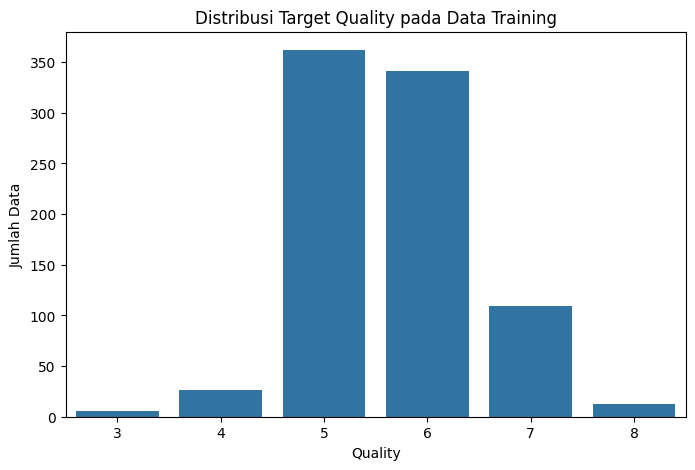

In [14]:
# Membuat grafik distribusi kelas quality pada data training
plt.figure(figsize=(8, 5))
sns.countplot(data=data_train, x="quality")
plt.title("Distribusi Target Quality pada Data Training")
plt.xlabel("Quality")
plt.ylabel("Jumlah Data")
plt.show()

**3. Pembuatan Model**

In [15]:
# Memisahkan fitur dan target dari data training
X = data_train.drop(columns=["Id", "quality"])
y = data_train["quality"]

Pada tahap ini, data training dipisahkan menjadi fitur dan target. Variabel X berisi fitur-fitur kimiawi anggur yang digunakan sebagai input model, sedangkan variabel y berisi target quality.
Kolom Id dihapus dari fitur karena hanya berfungsi sebagai identitas data. Kolom quality juga dipisahkan karena menjadi target yang akan diprediksi. Dengan demikian, model akan belajar dari hubungan antara fitur kimiawi anggur dan nilai kualitas anggur.


In [16]:
# Menampilkan 5 baris pertama dari fitur training (setelah Id dan quality dikeluarkan)
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0


Ini adalah hasil 5 data pertama setelah kolomId dan quality pada data training dikeluarkan

In [17]:
#Menyiapkan fitur pada data testing
X_testing = data_test.drop(columns=["Id"])

Disini kolom Id dihapus dari fitur karena hanya berfungsi sebagai identitas data sama seperti data training

In [18]:
# Menampilkan 5 baris pertama fitur data testing setelah Id dikeluarkan
X_testing.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,6.8,0.61,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000
1,6.9,0.84,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333
2,7.0,0.58,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000
3,7.8,0.48,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000
4,12.5,0.60,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000


Ini adalah hasil 5 data pertama setelah kolom Id pada data testing dikeluarkan

In [19]:
#Menampilkan fitur yang akan digunakan pada data training
print("Fitur data training:")
print(X.columns.tolist())

#Menampilkan fitur yang akan digunakan pada data testing
print("\nFitur data testing:")
print(X_testing.columns.tolist())

Fitur data training:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Fitur data testing:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


Disini dilakukan pengecekan pada data training dan data testing. Nama fitur dari data training dan data testing harus sama agar model dapat melakukan prediksi dengan benar. Pada koding di atas terlihat bahwa fitur data training dan data testing sudah sama

In [20]:
# Mengimport fungsi train_test_split untuk membagi data menjadi data latih dan data validasi
from sklearn.model_selection import train_test_split

In [21]:
#Membagi data menjadi data latih dan data validasi
X_latih, X_validasi, y_latih, y_validasi = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Disini data training dibagi menjadi data latih dan data validasi. Data latih digunakan untuk melatih model, sedangkan data validasi digunakan untuk menguji kemampuan model pada data yang belum pernah dilihat saat pelatihan. test_size=0,2 berarti 20% data digunakan sebagai data validasi dan 80% sebagai data latih, random_state=42 digunakan agar hasil pembagian datanya tetap konsistem, dan stratify=y digunakan agar proporsi kelas quality tetap seimbang

In [22]:
#Menampilkan ukuran data latih dan data validasi
print("Ukuran X_latih:", X_latih.shape)
print("Ukuran X_validasi:", X_validasi.shape)
print("Ukuran y_latih:", y_latih.shape)
print("Ukuran y_validasi:", y_validasi.shape)

Ukuran X_latih: (685, 11)
Ukuran X_validasi: (172, 11)
Ukuran y_latih: (685,)
Ukuran y_validasi: (172,)


Disini terlihat ukuran dari masing-masing data latih dan data validasi setelah kita pisahkan

Metode Decision Tree

Decision Tree Classifier adalah metode klasifikasi berbasis pohon keputusan. Model ini bekerja dengan membuat aturan percabangan berdasarkan fitur-fitur yang tersedia untuk menentukan kelas target.

In [23]:
# Mengimport algoritma Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

In [24]:
# Membuat model Decision Tree Classifier
model_dt = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

Pada model Decision Tree digunakan parameter random_state=42 agar hasil model konsisten saat kode dijalankan ulang. Parameter class_weight="balanced" digunakan untuk membantu model memperhatikan kelas yang jumlah datanya lebih sedikit, sehingga model tidak terlalu condong ke kelas mayoritas.

In [25]:
# Melatih model Decision Tree menggunakan data latih
model_dt.fit(X_latih, y_latih)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

Model Decision Tree dilatih menggunakan data latih, yaitu X_latih sebagai fitur dan y_latih sebagai target. Pada proses ini, model mempelajari pola hubungan antara fitur kimiawi anggur dan nilai quality.

In [26]:
# Melakukan prediksi data validasi menggunakan model Decision Tree
prediksi_dt = model_dt.predict(X_validasi)

Setelah model Decision Tree dilatih, kita melakukan prediksi pada data validasi

In [27]:
# Menampilkan 10 hasil prediksi pertama dari model Decision Tree
prediksi_dt[:10]

array([5, 5, 6, 5, 7, 4, 6, 5, 6, 6])

Disini terlihat 10 hasil pertama dari haris prediksi

In [28]:
# Mengimport accuracy_score untuk menghitung akurasi model
from sklearn.metrics import accuracy_score

Disini kita mengimport accuracy_score yang dimana kita gunakan untuk melihat nilai akurasi pada model yang kita pakai lalu kita bandingkan

In [29]:
# Menghitung akurasi model Decision Tree pada data validasi
akurasi_dt = accuracy_score(y_validasi, prediksi_dt)

# Menampilkan hasil akurasi Decision Tree
print("Akurasi Decision Tree:", akurasi_dt)
print("Akurasi Decision Tree dalam persen:", akurasi_dt * 100)

Akurasi Decision Tree: 0.5058139534883721
Akurasi Decision Tree dalam persen: 50.58139534883721


Pada output di atas terlihat bahwa nilai akurasi Decision Tree adalah 0,50581. Semakin tinggi nilai akurasi, semakin baik kemampuan model dalam memprediksi kelas quality pada data validasi

Metode Random Forest

Random Forest Classifier adalah metode ensemble learning yang membangun banyak pohon keputusan. Setiap pohon menghasilkan prediksi, kemudian hasil dari banyak pohon tersebut digabungkan untuk menghasilkan prediksi akhir.

In [30]:
# Mengimport algoritma Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

In [31]:
# Membuat model Random Forest Classifier
model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

Parameter n_estimators=100 berarti model membangun 100 pohon keputusan. Jumlah pohon ini digunakan agar model lebih stabil dibandingkan hanya menggunakan satu Decision Tree. Parameter random_state=42 digunakan agar hasil model konsisten, sedangkan class_weight="balanced" digunakan untuk membantu menangani ketidakseimbangan jumlah data pada setiap kelas quality.

In [32]:
# Melatih model Random Forest menggunakan data latih
model_rf.fit(X_latih, y_latih)

RandomForestClassifier(class_weight='balanced', random_state=42)

Model Random Forest dilatih menggunakan data latih. Pada proses ini, model membangun banyak pohon keputusan dari data training dan mempelajari pola hubungan antara fitur kimiawi anggur dan nilai quality.

In [33]:
# Melakukan prediksi data validasi menggunakan model Random Forest
prediksi_rf = model_rf.predict(X_validasi)

Setelah model Random Forest dilatih, kita melakukan prediksi pada data validasi

In [34]:
# Menampilkan 10 hasil prediksi pertama dari model Random Forest
prediksi_rf[:10]

array([5, 5, 5, 5, 7, 5, 5, 5, 6, 6])

Seperti pada model Decision Tree, disini kita menampilkan 10 hasil pertama data validasi setelah diprediksi

In [35]:
# Menghitung akurasi model Random Forest pada data validasi
akurasi_rf = accuracy_score(y_validasi, prediksi_rf)

# Menampilkan hasil akurasi Random Forest
print("Akurasi Random Forest:", akurasi_rf)
print("Akurasi Random Forest dalam persen:", akurasi_rf * 100)

Akurasi Random Forest: 0.6569767441860465
Akurasi Random Forest dalam persen: 65.69767441860465


Pada output di atas terlihat bahwa nilai akurasi Decision Tree adalah 0,65697. Sama seperti Decision Tree, Semakin tinggi nilai akurasi, semakin baik kemampuan model dalam memprediksi kelas quality pada data validasi

In [36]:
# Membuat tabel perbandingan akurasi antara Decision Tree dan Random Forest
hasil_akurasi = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Akurasi": [akurasi_dt, akurasi_rf],
    "Akurasi (%)": [akurasi_dt * 100, akurasi_rf * 100]
})

Disini kita membuat tabel perbandingan akurasi antara model Desicion Tree dan Random Forest agar kita mudah membandingkannya

In [37]:
# Menampilkan tabel perbandingan akurasi model
hasil_akurasi

,Model,Akurasi,Akurasi (%)
0,Decision Tree,0.505814,50.581395
1,Random Forest,0.656977,65.697674


Berdasarkan tabel, terlihat bahwa Random Forest memiliki akurasi yang lebih tinggi daripada Decision Tree, sehingga disini dipilih model Random Forest sebagai model final

In [38]:
# Mengimport confusion_matrix dan classification_report untuk evaluasi detail model
from sklearn.metrics import confusion_matrix, classification_report

Setelah model final dipilih, kita melakukan evaluasi detail menggunakan confusion matrix dan classification report

In [39]:
# Menampilkan confusion matrix model Random Forest
print("Confusion Matrix Random Forest:")
print(confusion_matrix(y_validasi, prediksi_rf))

Confusion Matrix Random Forest:
[[ 0  0  1  0  0  0]
 [ 0  0  5  0  0  0]
 [ 0  0 61 11  1  0]
 [ 0  0 20 45  3  0]
 [ 0  0  0 16  6  0]
 [ 0  0  0  0  2  1]]


Confusion matrix menunjukkan perbandingan antara kelas aktual dan kelas hasil prediksi. Dari confusion matrix dapat dilihat kelas mana yang sering diprediksi benar dan kelas mana yang masih sering salah diklasifikasikan.

Berdasarkan confusion matrix, model Random Forest paling baik dalam mengenali kelas quality 5 dan quality 6. Hal ini terlihat dari jumlah prediksi benar pada diagonal utama, yaitu 61 data untuk quality 5 dan 45 data untuk quality 6. Namun, model masih belum optimal dalam mengenali kelas quality 3, 4, 7, dan 8. Kelas quality 3 dan 4 seluruhnya diprediksi sebagai quality 5, sedangkan sebagian besar quality 7 diprediksi sebagai quality 6. Kondisi ini menunjukkan bahwa model cenderung lebih kuat dalam memprediksi kelas yang jumlah datanya dominan, sedangkan kelas dengan jumlah data sedikit masih sulit dikenali dengan baik.

In [40]:
# Menampilkan classification report model Random Forest
print("Classification Report Random Forest:")
print(classification_report(y_validasi, prediksi_rf))

Classification Report Random Forest:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.70      0.84      0.76        73
           6       0.62      0.66      0.64        68
           7       0.50      0.27      0.35        22
           8       1.00      0.33      0.50         3

    accuracy                           0.66       172
   macro avg       0.47      0.35      0.38       172
weighted avg       0.63      0.66      0.63       172



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Berdasarkan classification report, model Random Forest memperoleh akurasi sebesar 0.66 atau sekitar 66%. Hal ini menunjukkan bahwa model mampu memprediksi sebagian besar data validasi dengan benar. Namun, performa model tidak merata pada seluruh kelas quality.

Model memiliki performa terbaik pada kelas quality 5 dan quality 6. Pada kelas quality 5, model memperoleh precision sebesar 0.70, recall sebesar 0.84, dan f1-score sebesar 0.76. Hal ini menunjukkan bahwa model cukup baik dalam mengenali data dengan quality 5. Pada kelas quality 6, model memperoleh precision sebesar 0.62, recall sebesar 0.66, dan f1-score sebesar 0.64, sehingga model juga cukup mampu mengenali kelas tersebut meskipun masih terdapat kesalahan prediksi.

Sebaliknya, model belum mampu mengenali kelas quality 3 dan quality 4 dengan baik karena precision, recall, dan f1-score pada kedua kelas tersebut bernilai 0.00. Hal ini menunjukkan bahwa data pada kelas tersebut tidak berhasil diprediksi dengan benar oleh model. Untuk kelas quality 7 dan quality 8, performa model juga masih terbatas karena nilai recall yang rendah. Kondisi ini kemungkinan disebabkan oleh jumlah data pada kelas-kelas tersebut yang lebih sedikit dibandingkan quality 5 dan quality 6.

Nilai macro average f1-score sebesar 0.38 menunjukkan bahwa performa model secara rata-rata pada semua kelas masih belum merata. Sementara itu, weighted average f1-score sebesar 0.63 menunjukkan bahwa performa model lebih baik ketika mempertimbangkan jumlah data pada setiap kelas. Dengan demikian, model Random Forest cukup baik dalam memprediksi kelas mayoritas, terutama quality 5 dan 6, tetapi masih kurang optimal dalam mengenali kelas minoritas seperti quality 3, 4, 7, dan 8.

In [41]:
# Membuat ulang model Random Forest sebagai model final yang akan dilatih menggunakan seluruh data training
model_final = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

Setelah model dievaluasi, Random Forest digunakan sebagai model final. Model final dilatih kembali menggunakan seluruh data training, yaitu seluruh fitur pada X dan target pada y.



In [42]:
# Melatih model final menggunakan seluruh fitur dan target dari data training
model_final.fit(X, y)

RandomForestClassifier(class_weight='balanced', random_state=42)

Kode model_final.fit(X, y) berarti model final belajar dari seluruh data training. Tahap ini dilakukan agar model memperoleh informasi yang lebih lengkap sebelum digunakan untuk memprediksi data testing.

Model final tidak lagi hanya dilatih menggunakan X_latih dan y_latih, karena tahap validasi sudah dilakukan sebelumnya. Setelah model dianggap cukup baik, seluruh data training digunakan untuk membangun model akhir.

**4. Prediksi Data Uji**

In [43]:
# Memprediksi nilai quality pada data testing menggunakan model final
prediksi_quality_testing = model_final.predict(X_testing)

Pada tahap ini, model final digunakan untuk memprediksi nilai quality pada data testing. Data testing hanya berisi fitur kimiawi anggur dan belum memiliki kolom quality.

Hasil dari proses ini adalah prediksi nilai kualitas anggur untuk setiap data pada data_testing.csv. Prediksi inilah yang menjadi hasil akhir

In [44]:
# Menampilkan 10 hasil prediksi pertama pada data testing
prediksi_quality_testing[:10]

array([5, 6, 5, 5, 5, 6, 5, 5, 5, 5])

Ini adalah hasil 10 prediksi pertama pada testing

In [45]:
# Membuat dataframe hasil prediksi yang hanya berisi kolom Id dan quality
hasil_prediksi = pd.DataFrame({
    "Id": data_test["Id"],
    "quality": prediksi_quality_testing
})

Hasil prediksi disusun menjadi dataframe baru yang hanya berisi dua kolom, yaitu Id dan quality. Kolom Id diambil dari data testing, sedangkan kolom quality berisi hasil prediksi dari model final.

In [46]:
# Mengecek ukuran dataframe hasil prediksi
hasil_prediksi.shape

(286, 2)

Disini kita mengecek ukuran data hasil prediksi. Terlihat bahwa terdapat 286 baris dengan 2 kolom

In [47]:
# Mengecek nama kolom hasil prediksi
hasil_prediksi.columns.tolist()

['Id', 'quality']

Disini kita mengecek nama dari 2 kolom tadi. terlihat bahwa hasilnya adalah Id dan quality yang berarti sudah sesuai dengan keinginan kita

In [48]:
# Mengecek apakah terdapat missing value pada hasil prediksi
hasil_prediksi.isnull().sum()

,0
Id,0
quality,0


Kita juga mengecek missing values.Disini terlihat bahwa pada kolom Id dan quality menunjukkan angka 0, yang berarti tidak ada missing value

In [49]:
# Melihat distribusi hasil prediksi quality
hasil_prediksi["quality"].value_counts().sort_index()

,count
quality,
5,135
6,126
7,24
8,1


Disini kita mengecek juga apakah jumlah baris sudah sesuai dengan ukuran dataframe yang kita buat tadi.
Disini terlihat bahwa data Wine Quality yang memiliki kualitas 5 ada 135 Id, yang memiliki kualitas 6 ada 126 Id, yang memiliki kualitas 7 ada 24 Id, dn yang memiliki kualitas 8 ada 1 Id. Jumlahnya semuanya adalah 286 yang berarti sudah benar

**5. Menyimpan dan Mendownload Hasil Prediksi**

In [50]:
# Menentukan nama file hasil prediksi
nama_file = "hasilprediksi_015.csv"

Sebelum kita menyimpan file hasil prediksi, disini kita menentukan terlbeih dulu akan menyimpannya dengan nama apa

In [51]:
# Menyimpan hasil prediksi ke dalam file CSV
hasil_prediksi.to_csv(nama_file, index=False)

Setelah menentukan nama file nya, barulah kita menyimpan hasil prediksinya

In [52]:
# Menampilkan pemberitahuan bahwa file berhasil disimpan
print("File berhasil disimpan dengan nama:", nama_file)

File berhasil disimpan dengan nama: hasilprediksi_015.csv


Disini kita mengecek file data prediksinya tersimpan dengan nama apa. terlihat nama filenya sesuai dengan yang kita inginkan di atas

In [53]:
# Mengunduh file CSV hasil prediksi dari Google Colab ke komputer
files.download(nama_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Setelah semuanya sesuai, barulah di tahap ini kita mendownload file hasil prediksi menggunakan koding di atas